# 02 · Training and Validation

Load `../data/processed.npz` (from `01_data_prep.ipynb`), then:
1. **Main model**: a simple regression MLP — a single output node, linear output, **MSE** loss; predictions are rounded and clipped to 1–8. This matches the assignment text and the lecture (PPT) approach.
2. **Dropout / BatchNorm ablation**: run four configurations (Baseline / Dropout only / BN only / Both) with everything else identical, to study their effect on performance and overfitting.
3. **Evaluate** with **Quadratic Weighted Kappa (QWK)**, recording both **train loss and val loss** each epoch so overfitting is visible.
4. **Submission**: predict test.csv with the best configuration and write `../results/manual_results.csv`.
5. **Extension (CORAL)**: a dedicated ordinal-regression method, compared against the MSE version.

> Prerequisite: run `01_data_prep.ipynb` end-to-end first so that `../data/processed.npz` exists.

## Part 1: Load the processed data

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import cohen_kappa_score

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: mps


In [2]:
data = np.load("../data/processed.npz", allow_pickle=True)
Xtr = data["Xtr"].astype("float32")
Xva = data["Xva"].astype("float32")
Xte = data["Xte"].astype("float32")
ytr = data["ytr"].astype("int64")   # 1..8
yva = data["yva"].astype("int64")   # 1..8
test_ids = data["test_ids"]

IN_DIM = Xtr.shape[1]
print("Xtr:", Xtr.shape, " Xva:", Xva.shape, " Xte:", Xte.shape)
print("classes:", sorted(np.unique(ytr)))

Xtr: (47504, 150)  Xva: (11877, 150)  Xte: (19765, 150)
classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


## Part 2: Model definition (regression MLP with BN / Dropout switches)

The main model follows the assignment / lecture approach directly:
- The MLP ends in **a single output node** `nn.Linear(d, 1)` with **no activation** (linear output).
- Trained with **MSE loss**: we treat the ordinal label 1–8 as a continuous target and let the network regress toward it.
- **Prediction**: round the continuous output and clip it into [1, 8].

To run the ablation, `RegMLP` takes two switches — `use_bn` and `use_dropout` — so the *only* thing that changes across experiments is whether BatchNorm / Dropout layers are inserted. Everything else (layer sizes, learning rate, epochs, seed, optimizer) is held fixed.

In [3]:
class RegMLP(nn.Module):
    """Regression MLP: single linear output node, trained with MSE.
    use_bn / use_dropout toggle BatchNorm / Dropout for the ablation study."""
    def __init__(self, in_dim, hidden=(256, 128), use_bn=True, use_dropout=True, p_drop=0.3):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers.append(nn.Linear(d, h))
            if use_bn:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if use_dropout:
                layers.append(nn.Dropout(p_drop))
            d = h
        layers.append(nn.Linear(d, 1))     # single output node, linear (no activation)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)      # (N,)


@torch.no_grad()
def predict_continuous(model, X, batch=4096):
    """Raw continuous regression output."""
    model.eval()
    out = []
    for i in range(0, len(X), batch):
        xb = torch.from_numpy(X[i:i + batch]).to(device)
        out.append(model(xb).cpu().numpy())
    return np.concatenate(out)


def to_labels(cont):
    """Round the continuous prediction and clip into [1, 8]."""
    return np.clip(np.rint(cont), 1, 8).astype(int)

## Part 3: Dropout / BatchNorm ablation experiments

Assignment requirement: *"Experiment with dropout and batch normalization layers to study their effects on model performance."*

We run four configurations with identical settings otherwise:

| Experiment | Dropout | BN |
|-----------|---------|----|
| Baseline | no | no |
| Dropout only | yes | no |
| BN only | no | yes |
| Both | yes | yes |

Each epoch we record **train loss, val loss, and val QWK**. Train vs. val loss is what reveals overfitting (train loss keeps dropping while val loss starts rising).

In [4]:
# Training data with float targets for MSE.
train_ds = TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr.astype("float32")))


def train_model(use_bn, use_dropout, epochs=60, lr=1e-3, seed=SEED):
    # Reset seeds so every configuration sees the same init / shuffles.
    torch.manual_seed(seed)
    np.random.seed(seed)
    g = torch.Generator(); g.manual_seed(seed)
    loader = DataLoader(train_ds, batch_size=512, shuffle=True, generator=g)

    model = RegMLP(IN_DIM, use_bn=use_bn, use_dropout=use_dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    mse = nn.MSELoss()

    hist = []                       # (epoch, train_loss, val_loss, val_qwk)
    best_qwk, best_epoch, best_state = -1.0, -1, None
    yva_f = yva.astype("float32")

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = mse(model(xb), yb)
            loss.backward()
            opt.step()
            running += loss.item() * len(xb)
        train_loss = running / len(train_ds)

        # Validation: MSE loss + QWK
        val_cont = predict_continuous(model, Xva)
        val_loss = float(np.mean((val_cont - yva_f) ** 2))
        val_qwk = cohen_kappa_score(yva, to_labels(val_cont), weights="quadratic")
        hist.append((epoch, train_loss, val_loss, val_qwk))

        if val_qwk > best_qwk:
            best_qwk, best_epoch = val_qwk, epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    return {"history": np.array(hist), "best_qwk": best_qwk, "best_epoch": best_epoch,
            "best_state": best_state, "use_bn": use_bn, "use_dropout": use_dropout}

In [5]:
configs = [
    ("Baseline",     False, False),
    ("Dropout only", False, True),
    ("BN only",      True,  False),
    ("Both",         True,  True),
]

results = {}
rows = []
for name, bn, dp in configs:
    print(f"training: {name} (BN={bn}, Dropout={dp}) ...")
    r = train_model(use_bn=bn, use_dropout=dp)
    results[name] = r
    h = r["history"]
    rows.append({
        "config": name, "BN": bn, "Dropout": dp,
        "best_epoch": r["best_epoch"],
        "best_val_QWK": round(r["best_qwk"], 4),
        "train_loss_final": round(h[-1, 1], 4),
        "val_loss_final": round(h[-1, 2], 4),
        "overfit_gap": round(h[-1, 2] - h[-1, 1], 4),   # val_loss - train_loss at the end
    })

summary = pd.DataFrame(rows)
print()
summary

training: Baseline (BN=False, Dropout=False) ...


training: Dropout only (BN=False, Dropout=True) ...


training: BN only (BN=True, Dropout=False) ...


training: Both (BN=True, Dropout=True) ...


,config,BN,Dropout,best_epoch,best_val_QWK,train_loss_final,val_loss_final,overfit_gap
0,Baseline,False,False,15,0.5891,0.9148,5.6007,4.6859
1,Dropout only,False,True,38,0.5933,2.8888,3.7236,0.8348
2,BN only,True,False,8,0.5855,1.0490,5.1527,4.1037
3,Both,True,True,53,0.6059,2.6564,3.8395,1.1831


## Part 4: Results — overfitting analysis

The plots below show **train loss vs. val loss** for each configuration. Overfitting looks like: train loss keeps falling while val loss flattens or rises, and the gap between the two widens.

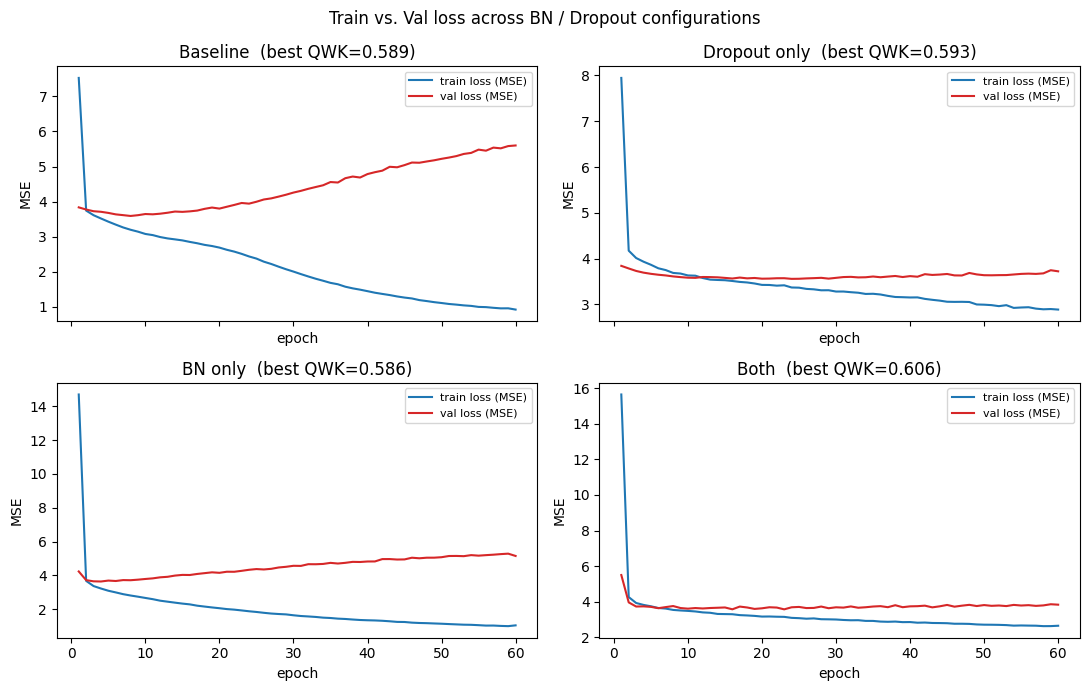

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for ax, (name, _, _) in zip(axes.flat, configs):
    h = results[name]["history"]
    ax.plot(h[:, 0], h[:, 1], color="tab:blue", label="train loss (MSE)")
    ax.plot(h[:, 0], h[:, 2], color="tab:red", label="val loss (MSE)")
    ax.set_title(f"{name}  (best QWK={results[name]['best_qwk']:.3f})")
    ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.legend(fontsize=8)
fig.suptitle("Train vs. Val loss across BN / Dropout configurations")
fig.tight_layout(); plt.show()

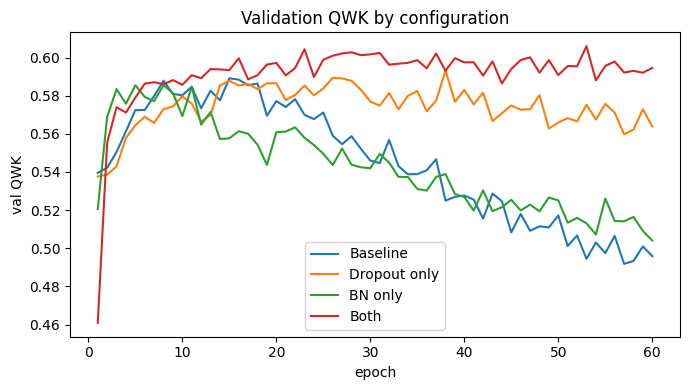

In [7]:
# Val QWK curves on one axis for a direct comparison.
plt.figure(figsize=(7, 4))
for name, _, _ in configs:
    h = results[name]["history"]
    plt.plot(h[:, 0], h[:, 3], label=name)
plt.xlabel("epoch"); plt.ylabel("val QWK"); plt.title("Validation QWK by configuration")
plt.legend(); plt.tight_layout(); plt.show()

**Observations (actual results):**

| Config | BN | Dropout | best val QWK | final train loss | final val loss | overfit gap |
|--------|----|---------|-------------:|-----------------:|---------------:|------------:|
| Baseline | ✗ | ✗ | 0.5891 (epoch 15) | 0.915 | 5.601 | **4.686** |
| Dropout only | ✗ | ✓ | 0.5933 (epoch 38) | 2.889 | 3.724 | **0.835** |
| BN only | ✓ | ✗ | 0.5855 (epoch 8) | 1.049 | 5.153 | 4.104 |
| Both | ✓ | ✓ | **0.6059** (epoch 53) | 2.656 | 3.840 | 1.183 |

- **Baseline (no BN, no Dropout) overfits the most.** The train loss collapses to 0.915 (the network nearly memorizes the training set) while the val loss stays at 5.601 — an overfit gap of **4.69**, the widest of all. Its best QWK peaks early (epoch 15) and then degrades.
- **Dropout is the key regularizer.** Adding Dropout keeps the train loss higher (2.889, i.e. the network can no longer memorize) and pulls the val loss down from 5.601 to 3.724, shrinking the overfit gap from **4.69 to 0.83**. This directly quantifies what Dropout does.
- **BN only mainly speeds up convergence** (best epoch is 8, far earlier) but barely helps overfitting: its gap (4.10) is close to the Baseline's. So BN and Dropout serve different purposes.
- **Both is the best overall**: highest val QWK (0.6059) with a small overfit gap (1.18). BN stabilizes training while Dropout controls overfitting — the two are complementary.

For reference, the earlier CORAL run also overfit (val QWK peaked ~0.615 around epoch 15–20, then drifted down toward ~0.60), consistent with the Baseline / BN-only behavior here.

## Part 5: Validation and submission (best configuration)

Pick the configuration with the highest validation QWK, restore its best checkpoint, and write the submission.

In [8]:
import os

best_name = max(results, key=lambda k: results[k]["best_qwk"])
r = results[best_name]
print(f"best configuration: {best_name}  (val QWK={r['best_qwk']:.4f}, epoch {r['best_epoch']})")

# Rebuild the model with the same switches and load the best checkpoint.
best_model = RegMLP(IN_DIM, use_bn=r["use_bn"], use_dropout=r["use_dropout"]).to(device)
best_model.load_state_dict(r["best_state"])

# Sanity check on validation, then predict test.
val_qwk = cohen_kappa_score(yva, to_labels(predict_continuous(best_model, Xva)), weights="quadratic")
print(f"restored val QWK: {val_qwk:.4f}")

test_pred = to_labels(predict_continuous(best_model, Xte))
sub = pd.DataFrame({"Id": test_ids, "Response": test_pred.astype(int)})
os.makedirs("../results", exist_ok=True)
sub.to_csv("../results/manual_results.csv", index=False)
print("saved -> ../results/manual_results.csv", sub.shape)
sub.head()

best configuration: Both  (val QWK=0.6059, epoch 53)
restored val QWK: 0.6059
saved -> ../results/manual_results.csv (19765, 2)


,Id,Response
0,1,2
1,3,6
2,4,4
3,9,5
4,12,7


## Part 6 (Extension): CORAL ordinal regression

The MSE version above treats the label as a plain number. **CORAL** is a method designed specifically for *ordinal* targets. Instead of predicting "which level", it splits the problem into 7 yes/no questions — "is the risk > 1? > 2? … > 7?" — and the number of "yes" answers is the predicted level.

Relation to the assignment: the network still has **a single score node** `g(x) = Linear(d, 1)`; CORAL then adds 7 learnable cut points (ordered biases), so it can be read as "a single output node + learned thresholds". Because all 7 logits share the same `g(x)`, the predicted probabilities are rank-monotonic (no "P(>5) > P(>3)" contradictions).

We keep BN + Dropout here (the best config) and compare its QWK against the MSE version.

In [9]:
NUM_CLASSES = 8


class CoralMLP(nn.Module):
    """MLP backbone -> single score g(x); CORAL adds K-1 ordered bias terms."""
    def __init__(self, in_dim, num_classes, hidden=(256, 128), p_drop=0.3):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p_drop)]
            d = h
        self.backbone = nn.Sequential(*layers)
        self.score = nn.Linear(d, 1, bias=False)                      # single shared score
        self.coral_bias = nn.Parameter(torch.zeros(num_classes - 1))  # K-1 ordered thresholds

    def forward(self, x):
        return self.score(self.backbone(x)) + self.coral_bias         # (N, K-1)


def labels_to_levels(y0, num_classes):
    ks = torch.arange(num_classes - 1, device=y0.device)
    return (y0.unsqueeze(1) > ks.unsqueeze(0)).float()


def coral_loss(logits, levels):
    per_task = F.logsigmoid(logits) * levels + (F.logsigmoid(logits) - logits) * (1 - levels)
    return (-per_task.sum(dim=1)).mean()


@torch.no_grad()
def coral_predict(model, X, batch=4096):
    model.eval()
    out = []
    for i in range(0, len(X), batch):
        xb = torch.from_numpy(X[i:i + batch]).to(device)
        out.append((torch.sigmoid(model(xb)) > 0.5).sum(dim=1).cpu().numpy())
    return np.concatenate(out) + 1     # 1..K

In [10]:
torch.manual_seed(SEED); np.random.seed(SEED)
g = torch.Generator(); g.manual_seed(SEED)

ytr0 = torch.from_numpy((ytr - 1).astype("int64"))            # 0..7
coral_ds = TensorDataset(torch.from_numpy(Xtr), ytr0)
coral_loader = DataLoader(coral_ds, batch_size=512, shuffle=True, generator=g)

coral = CoralMLP(IN_DIM, NUM_CLASSES).to(device)
opt = torch.optim.Adam(coral.parameters(), lr=1e-3, weight_decay=1e-5)

coral_best_qwk, coral_best_state = -1.0, None
for epoch in range(1, 61):
    coral.train()
    for xb, yb in coral_loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = coral_loss(coral(xb), labels_to_levels(yb, NUM_CLASSES))
        loss.backward(); opt.step()
    qwk = cohen_kappa_score(yva, coral_predict(coral, Xva), weights="quadratic")
    if qwk > coral_best_qwk:
        coral_best_qwk = qwk
        coral_best_state = {k: v.detach().cpu().clone() for k, v in coral.state_dict().items()}
    if epoch % 10 == 0 or epoch == 1:
        print(f"epoch {epoch:3d} | val QWK {qwk:.4f}")

print(f"\nCORAL best val QWK: {coral_best_qwk:.4f}")

epoch   1 | val QWK 0.5193


epoch  10 | val QWK 0.6061


epoch  20 | val QWK 0.6155


epoch  30 | val QWK 0.6117


epoch  40 | val QWK 0.6027


epoch  50 | val QWK 0.6057


epoch  60 | val QWK 0.6006

CORAL best val QWK: 0.6195


In [11]:
# Compare MSE main model vs. CORAL extension
compare = pd.DataFrame({
    "method": [f"MSE regression ({best_name})", "CORAL ordinal regression"],
    "val_QWK": [round(r["best_qwk"], 4), round(coral_best_qwk, 4)],
})
compare

,method,val_QWK
0,MSE regression (Both),0.6059
1,CORAL ordinal regression,0.6195


**Comparison conclusion (actual results):**

| Method | val QWK |
|--------|--------:|
| MSE regression (Both, BN+Dropout) | 0.6059 |
| **CORAL ordinal regression** | **0.6195** |

- The MSE regression model is the direct approach required by the assignment (single output node, linear output, MSE loss, round-and-clip to 1–8); its best validation QWK is **0.6059**.
- CORAL, a purpose-built ordinal method, reaches **0.6195** — an improvement of **+0.0136** — showing that explicitly modeling the ordinal structure (rank-monotonic thresholds) helps on QWK.
- Trade-off: the MSE version is simpler and more interpretable and satisfies the assignment brief; CORAL adds a small but consistent gain by respecting the ordering of the classes. Both submissions are saved — `manual_results.csv` (MSE) and `manual_results_coral.csv` (CORAL).

In [12]:
# Save the CORAL predictions too (higher QWK) as a separate submission file.
coral.load_state_dict(coral_best_state)          # restore best CORAL checkpoint
coral_test_pred = coral_predict(coral, Xte)      # 1..8

coral_sub = pd.DataFrame({"Id": test_ids, "Response": coral_test_pred.astype(int)})
coral_sub.to_csv("../results/manual_results_coral.csv", index=False)
print(f"saved -> ../results/manual_results_coral.csv {coral_sub.shape}  (val QWK={coral_best_qwk:.4f})")
coral_sub.head()

saved -> ../results/manual_results_coral.csv (19765, 2)  (val QWK=0.6195)


,Id,Response
0,1,2
1,3,7
2,4,6
3,9,6
4,12,8
